In [2]:
%load_ext autoreload
%autoreload 2

# Global libraries
import os
import torch
from torch.utils.data import DataLoader
from collections import defaultdict
from torchviz import make_dot 
from PIL import ImageFont
from torchinfo import summary

# Local libraries enivironment loading
import sys
from pathlib import Path
path_Project = Path(os.getcwd()).parent.parent
path_Git = path_Project.parent

def IncludeDirectory(path, index = 0, indexStop = -1):
    if(os.path.exists(path) and (index <= indexStop or indexStop == -1)):
        print(path)
        sys.path.append(path)
        children = os.listdir(path)
        for i in range(len(children)):
            pathChild = os.path.join(path,children[i])
            if(os.path.isdir(pathChild)):
                IncludeDirectory(pathChild, index + 1, indexStop)

# Activate the function
IncludeDirectory(path_Git,0,1)


c:\Users\r.van.der.wal\Documents\GitHub
c:\Users\r.van.der.wal\Documents\GitHub\pred_RT


In [3]:

#Local libraries
from src.config_presets.tools.get_config import get_config
from src.dataset.load_dataset import load_dataset, load_dataset_total
from src.models.tools.save_model import save_model
from src.training.train_multi import train
from src.utils.logging.logging import setup_logging
from src.utils.parse_args import parse_args
from src.utils.set_random_seed import set_random_seed
from src.hyper_opt.hyperHandler import HyperTuning_Handler
from src.utils.fileHandler import create_file, create_textfile
from src.dataset.ToxDataset import *

c:\Users\r.van.der.wal\.conda\envs\test-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [31]:
# Load the config
config = get_config('DETOXLung_config', pathGiven = str(path_Project))

# Set the config to wanted augmentations
config['data']['augmentation']['list']['flip']['Isenabled'] = False
config['data']['augmentation']['list']['affine']['Isenabled'] = False
config['data']['augmentation']['list']['rotate']['Isenabled'] = True

# Disable randomness
set_random_seed(config['general']['seed'])

c:\Users\r.van.der.wal\Documents\GitHub\pred_RT\src\config_presets\Base_config.yaml
c:\Users\r.van.der.wal\Documents\GitHub\pred_RT\src\config_presets\DETOXLung_config.yaml


In [32]:
# Load the dataset
dataset, metadata = load_dataset_total(config)
train_loader = DataLoader(dataset[0][0], batch_size=config['training']['batch_size'], shuffle=True)
val_loader = DataLoader(dataset[1][0], batch_size=config['training']['batch_size'], shuffle=True)

Class balance in training dataset is 0.13996316758747698


In [33]:
# Show a picture of the dataset
for data in train_loader._get_iterator():
    print("Data is obtained")
    break

Data is obtained


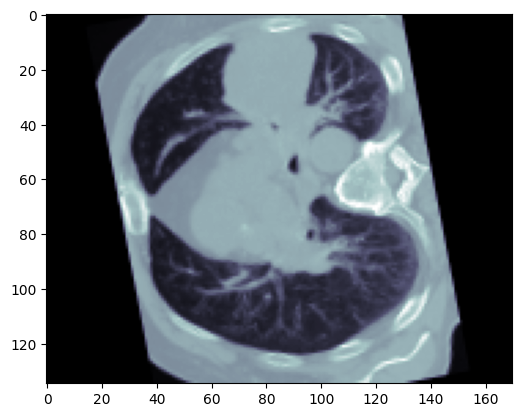

In [41]:
import matplotlib.pyplot as plt

CT_image = data[0][11,0,:,:,:]
plt.imshow(CT_image[100,:,:], cmap = "bone")

# Found that the translation is always the same! This is not wanted! It should be a range of translations

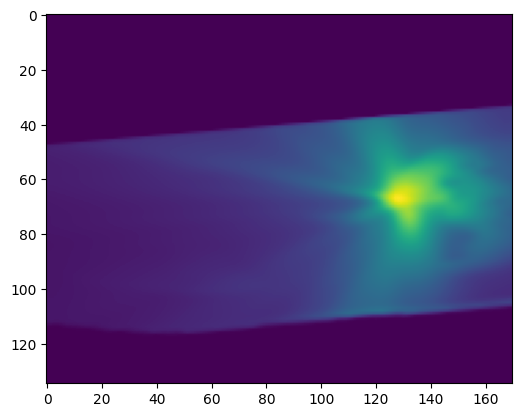

In [31]:
plt.imshow(CT_image[120,:,:])

In [197]:
#sum(train_loader.dataset.df[config['columns']['label']].toarray() == 1)
array = sum(train_loader.dataset.df[config['columns']['label']].to_numpy() == 1)/len(train_loader.dataset.df)
value = array[0]